# Vision Transformer Reimplementation

Author: Anonymous

### 0. Import Section

In [1]:
import numpy as np

from tqdm import tqdm, trange

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import torch.optim
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
import torchvision
from torchvision.datasets import CIFAR10

### 1. Training and testing loops

In [2]:
'''
This code (training and testing loops) is based on the code I have written
for assignment 3 in ECE57000.
'''
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# training loop for 1 epoch
def train(model: nn.Module, criterion: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader, epoch: int=0):
  tloss = []

  for batch, (x, y) in enumerate(train_loader):
    x, y = x.to(device), y.to(device)
    out = model(x)
    loss = criterion(out, y)

    tloss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % (len(train_loader) // 10) == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.2f}')

  return tloss

# testing loop for 1 epoch
def test(model: nn.Module, criterion: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader, epoch: int=0):
  model.eval()
  tloss = 0
  correct = 0
  pred = torch.tensor([])
  output = {}
  total = len(test_loader.dataset)

  with torch.no_grad():
    for x, y in test_loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      tloss += criterion(out, y).detach().cpu().item() * x.size(0)
      p = out.data.max(1, keepdim=True)[1]
      correct += p.eq(y.data.view_as(p)).sum()
      pred = torch.cat((pred, p.cpu()), dim=0)

  l = tloss / total
  acc = correct / total
  print(f"Test result on epoch {epoch}: Avg loss: {l:.2f}, Acc: {100*acc:.2f}%")

  return pred

### 2. Vision Transformer
ViT class contains all the necessary tools to implement a vision transformer. It incorporates:
  1. Dividing the input image into patches
  2. Linear projection (implemented in the ViT class)
  3. Appending positional embedding
  4. Transformer encoder, which consists of:
*   Layer normalization
*   Multi-head self-attention
*   Residual connection
*   Second layer normalization
*   Multi-layer perceptron
*   Second residual connection
  5. Classification multi-layer perceptron


### 2.1 Patching

In [5]:
'''
This function transforms square images of size (W x W) into n_patches
of size (W/n_patches x W/n_patches)
'''
def into_patches(n_patches, images):
  number_of_img, channels, width, height = images.shape
  patches = torch.zeros(number_of_img,
                        n_patches ** 2,
                        height * width * channels // (n_patches ** 2))

  # number of patches
  p_size = width // n_patches

  # iterate through images and patch each square of p_size x p_size
  for z, img in enumerate(images):
    for i in range(n_patches):
      for j in range(n_patches):
        p = img[:, i * p_size:(i + 1) * p_size, j * p_size:(j + 1) * p_size]
        patches[z, i * n_patches + j] = p.flatten()

  return patches

### 2.3 Positional Embeddings

In [6]:
'''
This code (Positinal Encoding class) is based on the code I have written
for assignment 4 in ECE57000.
'''
class PositionalEncoding:
  def __init__(self, d_model, max_len):
        self.d_model = d_model
        self.max_len = max_len
        self.positional_encoding = self._get_positional_encoding()

  def _get_positional_encoding(self):
        pos_enc = torch.zeros((self.max_len, self.d_model), dtype=torch.float64)

        for i in range(self.max_len):
          for j in range(self.d_model // 2):
            pos_enc[i, 2 * j] = math.sin(i / math.pow(10000,
                                                      2 * j / self.d_model))
            pos_enc[i, 2 * j + 1] = math.cos(i / math.pow(10000,
                                                          2 * j / self.d_model))

        return pos_enc

  def get_encoding(self):
        return self.positional_encoding

def add_positional_encoding(word_embeddings, positional_encodings):
    return word_embeddings + positional_encodings

### 2.4.2 Multi-Head Self-Attention

In [11]:
'''
This code (create_mask(), attention_score(), self-attention class,
multi-head attention class) is based on the code I have written
for assignment 4 in ECE57000.
'''
def attention_score(Q, K, V):
  d_k = Q.size(-1)
  a = torch.bmm(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

  weights = torch.softmax(a, dim=-1)
  output = torch.bmm(weights, V)
  return output, weights

class SelfAttention(torch.nn.Module):
  def __init__(self, d_in, d_k, d_v):
    super(SelfAttention, self).__init__()
    self.d_in = d_in
    self.d_k = d_k
    self.d_v = d_v
    self.wq = nn.Linear(self.d_in, self.d_k)
    self.wk = nn.Linear(self.d_in, self.d_k)
    self.wv = nn.Linear(self.d_in, self.d_v)

  def forward(self, X):
    self.Q = self.wq(X)
    self.K = self.wk(X)
    self.V = self.wv(X)

    output, weigths = attention_score(self.Q, self.K, self.V)
    return output

class MultiHeadSelfAttention(nn.Module):
  def __init__(self, d_in, d_k, d_v, num_heads):
    super(MultiHeadSelfAttention, self).__init__()
    self.d_in = d_in
    self.d_k = d_k
    self.d_v = d_v
    self.h = num_heads
    self.out_l = nn.Linear((d_v // num_heads) * num_heads, d_v)
    self.heads = nn.ModuleList([SelfAttention(
        d_in, d_k // num_heads,
        d_v // num_heads) for i in range(num_heads)])

  def forward(self, X, mask=None):
    a_outs = []

    for h in self.heads:
      a_outs.append(h.forward(X))

    m = torch.cat(a_outs, dim=-1)
    multi_ha = self.out_l(m)

    return multi_ha

### 2.4 Transformer Encoder

In [15]:
'''
This class contains the implementation of a transformer encoder.
'''
class TransformerEncoder(nn.Module):
  def __init__(self, h, heads):
    super(TransformerEncoder, self).__init__()
    self.h = h
    self.heads = heads
    # 2.4.1 Layer Normalization
    self.normalization = nn.LayerNorm(self.h)
    # 2.4.2 Multi-Head Self-Attention
    self.multi_head_sa = MultiHeadSelfAttention(self.h, self.h, self.h,
                                                self.heads)
    # Dropout Layer
    self.dropout = nn.Dropout(0.1)
    # 2.4.4 Second Layer Normalization
    self.normalization2 = nn.LayerNorm(self.h)
    # 2.4.5 Multi-Layer Perceptron
    self.mlp = nn.Sequential(nn.Linear(self.h, 4 * self.h), nn.GELU(),
                             nn.Dropout(0.1),
                             nn.Linear(4 * self.h, self.h),
                             nn.Dropout(0.1))

  def forward(self, X):
    # Apply layer normalization
    temp = self.normalization(X)
    # Apply multi-head self-attention
    temp = self.multi_head_sa.forward(temp)

    # 2.4.3 Residual Connection
    temp = X + temp
    out = temp

    # Apply second normalization
    temp = self.normalization2(temp)

    # MLP
    temp = self.mlp(temp)

    # 2.4.6 Second Residual Connection
    return out + temp

In [16]:
'''
This class implements a vision transformer architecture
'''
class ViT(nn.Module):
  def __init__(self, n_patches, n_channels, img_size, h, heads, trans, out):
    super(ViT, self).__init__()
    '''
    number of patches = 8, therefore for CIFAR-10 with images of size (32x32)
    the patches will have size (4x4)
    '''
    self.n_patches = n_patches
    self.n_channels = n_channels
    self.img_size = img_size
    self.h = h
    self.heads = heads
    self.trans = trans
    self.out = out

    # 2.2 Linear Projection
    self.lin_proj = nn.Linear(
        int(self.n_channels * (self.img_size / self.n_patches) ** 2), self.h)

    # CLS Token
    self.cls_token = nn.Parameter(torch.zeros(1, self.h))

    # Positional Embeddings
    self.pos_embeddings = PositionalEncoding(self.h, self.n_patches ** 2 + 1)

    # Transformer Encoder(s)
    self.trans_enc = nn.ModuleList()
    for i in range(self.trans):
      self.trans_enc.append(TransformerEncoder(self.h, self.heads))

    # 2.5 Classification Multi-Layer Perceptron
    self.cmlp = nn.Sequential(nn.Linear(self.h, self.out))


  def forward(self, images):
    device = images.device
    dtype = images.dtype

    # Split images into patches
    patches = into_patches(self.n_patches, images).to(device, dtype=dtype)

    # Create linear projection of the flattened patches
    proj_patches = self.lin_proj(patches)

    # Append the CLS token
    temp = []
    for i in range(len(proj_patches)):
      temp.append(torch.vstack((self.cls_token.to(device, dtype=dtype), proj_patches[i])))
    proj_patches = torch.stack(temp)

    # Add positional embeddings
    enc = self.pos_embeddings.get_encoding().to(device, dtype=dtype)
    encoder_in = add_positional_encoding(proj_patches, enc)

    # Pass through transformer encoders
    out = encoder_in
    for te in self.trans_enc:
      out = te(out)

    # Extract CLS token
    out = out[:, 0, :]

    # MLP
    out = self.cmlp(out)

    return out


### Train and Test ViT on CIFAR-10 Dataset

In [22]:
'''
The code in this block is based on the code from assignment 3 for ECE57000
'''
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog',
           'horse', 'ship', 'truck')

batch_train, batch_test = 128, 128

transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                      torchvision.transforms.Normalize((0.5, 0.5, 0.5),
                       (0.5, 0.5, 0.5)),
                      torchvision.transforms.RandomHorizontalFlip()])

train_dataset = torchvision.datasets.CIFAR10('data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10('data', train=False,
                                            download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=batch_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=batch_test, shuffle=False)

vit = ViT(8, 3, 32, 64, 2, 6, 16).to(device)
optimizer = torch.optim.Adam(vit.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = CrossEntropyLoss()

for epoch in range(1, 8):
  train(vit, criterion, optimizer, train_loader, epoch)
  test(vit, criterion, test_loader, epoch)
  scheduler.step()

output = test(vit, criterion, test_loader, epoch)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1, Loss: 2.85
Epoch 1, Loss: 2.09
Epoch 1, Loss: 1.75
Epoch 1, Loss: 1.85
Epoch 1, Loss: 1.85
Epoch 1, Loss: 1.62
Epoch 1, Loss: 1.67
Epoch 1, Loss: 1.63
Epoch 1, Loss: 1.55
Epoch 1, Loss: 1.69
Epoch 1, Loss: 1.43
Test result on epoch 1: Avg loss: 1.40, Acc: 49.55%
Epoch 2, Loss: 1.42
Epoch 2, Loss: 1.44
Epoch 2, Loss: 1.33
Epoch 2, Loss: 1.31
Epoch 2, Loss: 1.48
Epoch 2, Loss: 1.27
Epoch 2, Loss: 1.35
Epoch 2, Loss: 1.34
Epoch 2, Loss: 1.35
Epoch 2, Loss: 1.17
Epoch 2, Loss: 1.21
Test result on epoch 2: Avg loss: 1.29, Acc: 53.15%
Epoch 3, Loss: 1.38
Epoch 3, Loss: 1.28
Epoch 3, Loss: 1.10
Epoch 3, Loss: 1.20
Epoch 3, Loss: 1.17
Epoch 3, Loss: 1.15
Epoch 3, Loss: 1.33
Epoch 3, Loss: 1.15
Epoch 3, Loss: 1.26
Epoch 3, Loss: 1.15
Epoch 3, Loss: 1.26
Test result on epoch 3: Avg loss: 1.21, Acc: 56.56%
Epoch 4, Loss: 1.07
Epoch 4, Loss: 1.12
Epoch 4, Loss: 1.23
Epoch 4, Loss: 1.11
Epoch 4, Loss: 1.05
Epoch 4,

### Plot Sample Test Data

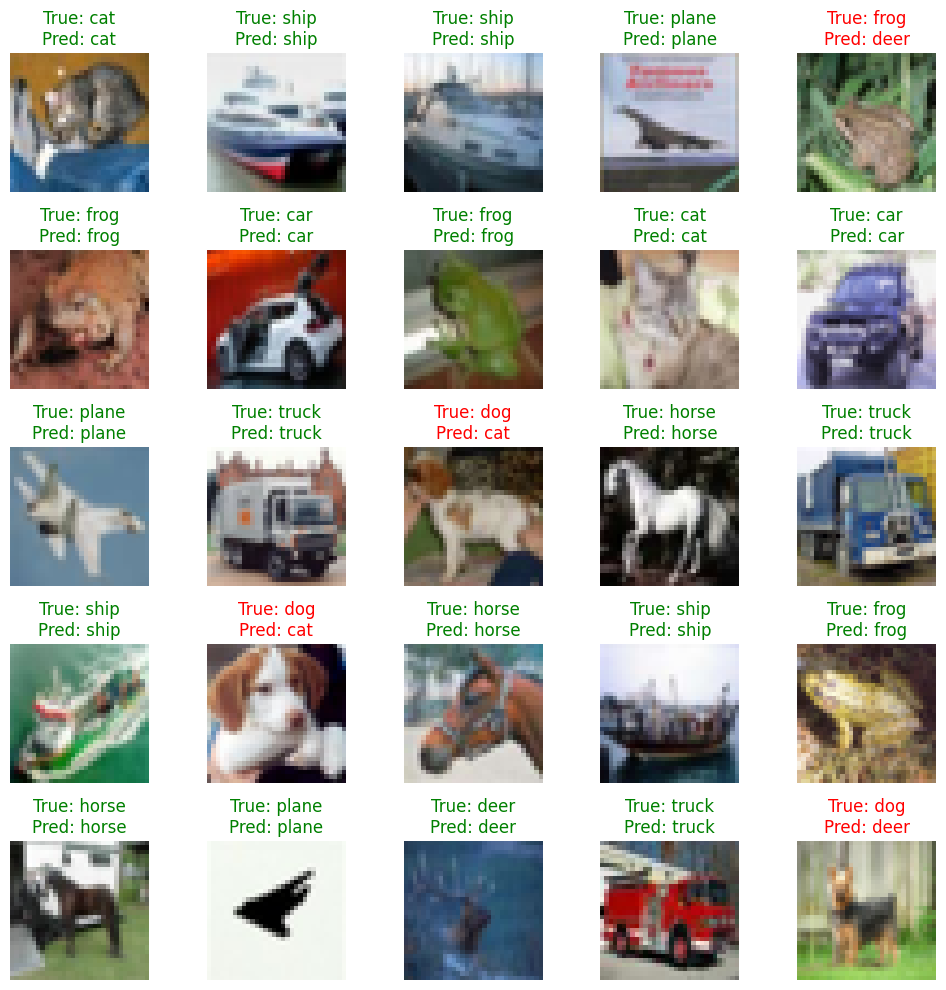

In [23]:
labels = test_dataset.targets
idx = []

for batch, (img, labels) in enumerate(test_loader):
  p = output[batch * len(labels):(batch + 1) * len(labels)]
  p = p.to(device)
  img, labels = img.to(device), labels.to(device)

  for i in range(len(labels)):
    idx.append((img[i], labels[i], p[i]))
    if len(idx) >= 25:
        break
  if len(idx) >= 25:
        break

fig, ax = plt.subplots(5, 5, figsize = (10,10))
for i in range(25):
  r = int(i // 5)
  c = int(i % 5)
  img, true_label, pred_label = idx[i]
  img = img.detach().cpu().permute(1, 2, 0)  # Rearrange dimensions for plotting
  img = img / 2 + 0.5  # Unnormalize the image

  ax[r, c].imshow(img)
  ax[r, c].axis('off')
  t = int(true_label.item())
  p = int(pred_label.item())
  if t == p:
    color = 'green'
  else:
    color = 'red'
  ax[r, c].set_title(f'True: {classes[t]}\nPred: {classes[p]}', color=color)

fig.tight_layout()
fig.show()